<a href="https://colab.research.google.com/github/sinhatanushree21/Time_Series_Analysis/blob/main/Time_series_with_multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
import yfinance as yf
import pandas as pd

# Download closing prices
disney_close = yf.download("DIS", start="2025-01-01", end="2025-12-31")['Close']
netflix_close = yf.download("NFLX", start="2025-01-01", end="2025-12-31")['Close']

# Combine into one DataFrame with aligned dates
stock_data = pd.concat([disney_close, netflix_close], axis=1)
stock_data.columns = ['Disney_close', 'Netflix_close']

# Drop missing rows (holidays, etc.)
stock_data = stock_data.dropna()

print(stock_data.head())


/tmp/ipython-input-594/2712855870.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  disney_close = yf.download("DIS", start="2025-01-01", end="2025-12-31")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-594/2712855870.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  netflix_close = yf.download("NFLX", start="2025-01-01", end="2025-12-31")['Close']
[*********************100%***********************]  1 of 1 completed

            Disney_close  Netflix_close
Date                                   
2025-01-02    109.607826      88.672997
2025-01-03    109.944115      88.105003
2025-01-06    109.835320      88.179001
2025-01-07    110.171593      87.918999
2025-01-08    108.559425      87.500000


In [3]:
from statsmodels.tsa.stattools import grangercausalitytests

# Test if Disney prices Granger-cause Netflix prices
grangercausalitytests(stock_data[['Netflix_close','Disney_close']], maxlag=14, verbose=True)
print()


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.1188  , p=0.1468  , df_denom=245, df_num=1
ssr based chi2 test:   chi2=2.1447  , p=0.1431  , df=1
likelihood ratio test: chi2=2.1355  , p=0.1439  , df=1
parameter F test:         F=2.1188  , p=0.1468  , df_denom=245, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.4545  , p=0.2356  , df_denom=242, df_num=2
ssr based chi2 test:   chi2=2.9690  , p=0.2266  , df=2
likelihood ratio test: chi2=2.9513  , p=0.2286  , df=2
parameter F test:         F=1.4545  , p=0.2356  , df_denom=242, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.8922  , p=0.4458  , df_denom=239, df_num=3
ssr based chi2 test:   chi2=2.7549  , p=0.4310  , df=3
likelihood ratio test: chi2=2.7396  , p=0.4335  , df=3
parameter F test:         F=0.8922  , p=0.4458  , df_denom=239, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.6880  , p=0.1535  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


**Since P value is not less than 0.05, fails to reject null hypothesis, means past values of disney doesnot effect the neflix stock price**

Checking which stock helps in finding netflix stock price

In [4]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# Step 1: Download Netflix + candidate stocks
tickers = ["DIS", "AAPL", "AMZN", "MSFT"]  # Disney, Apple, Amazon, Microsoft
data = yf.download(tickers + ["NFLX"], start="2025-01-01", end="2025-12-31")['Close']

# Step 2: Drop missing values (holidays, etc.)
data = data.dropna()

# Step 3: Add lagged Netflix column (yesterday’s price)
data['NFLX_lag1'] = data['NFLX'].shift(1)

# Drop the first row (NaN from shift)
data = data.dropna()

print(data.head())  # sanity check

# Step 4: Loop through each stock and test if it Granger-causes Netflix
for ticker in tickers:
    print(f"\nTesting if {ticker} Granger-causes Netflix...")
    try:
        results = grangercausalitytests(data[['NFLX', ticker]], maxlag=14, verbose=False)
        # Extract F-test p-values for each lag
        for lag in results.keys():
            f_test_pval = results[lag][0]['ssr_ftest'][1]
            print(f"Lag {lag}: p-value = {f_test_pval:.4f}")
    except Exception as e:
        print(f"Error testing {ticker}: {e}")


/tmp/ipython-input-594/2601306829.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers + ["NFLX"], start="2025-01-01", end="2025-12-31")['Close']
[*********************100%***********************]  5 of 5 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Ticker            AAPL        AMZN         DIS        MSFT       NFLX  \
Date                                                                    
2025-01-03  242.037811  224.190002  109.944115  419.292908  88.105003   
2025-01-06  243.668915  227.610001  109.835320  423.749756  88.179001   
2025-01-07  240.894073  222.110001  110.171593  418.322266  87.918999   
2025-01-08  241.381409  222.130005  108.559425  420.491272  87.500000   
2025-01-10  235.563187  218.940002  107.461571  414.935059  83.768997   

Ticker      NFLX_lag1  
Date                   
2025-01-03  88.672997  
2025-01-06  88.105003  
2025-01-07  88.179001  
2025-01-08  87.918999  
2025-01-10  87.500000  

Testing if DIS Granger-causes Netflix...
Lag 1: p-value = 0.1561
Lag 2: p-value = 0.2396
Lag 3: p-value = 0.4571
Lag 4: p-value = 0.1606
Lag 5: p-value = 0.3015
Lag 6: p-value = 0.3607
Lag 7: p-value = 0.4363
Lag 8: p-value = 0.3329
Lag 9: p-value = 0.4160
Lag 10: p-value = 0.5002
Lag 11: p-value = 0.5822
Lag 12: p-va

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Means apple stock data helps in predicting the future data of netflix
What “Lag 2” Means
- Lag 1 → yesterday’s Apple price helps predict today’s Netflix price.
- Lag 2 → Apple’s price from two days ago also adds predictive power.
- Together, this suggests Netflix’s movements are influenced by Apple’s recent history up to two days back.


In [7]:
from statsmodels.tsa.api import VAR

# Step 1: Download Apple and Netflix closing prices
data = yf.download(["AAPL", "NFLX"], start="2025-01-01", end="2025-12-31")['Close']

# Step 2: Drop missing values
data = data.dropna()

# Step 3: Fit a VAR model
model = VAR(data)
results = model.fit(maxlags=2)  # use 2 lags (based on your Granger test)

# Step 4: Print summary
print(results.summary())


/tmp/ipython-input-594/930445257.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["AAPL", "NFLX"], start="2025-01-01", end="2025-12-31")['Close']
[*********************100%***********************]  2 of 2 completed

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 28, Feb, 2026
Time:                     07:58:32
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    4.59320
Nobs:                     247.000    HQIC:                   4.50832
Log likelihood:          -1240.67    FPE:                    85.7240
AIC:                      4.45112    Det(Omega_mle):         82.3560
--------------------------------------------------------------------
Results for equation AAPL
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const          -0.579052         3.805573           -0.152           0.879
L1.AAPL         1.101195         0.067121           16.406           0.000
L1.NFLX        -0.221936         0.129703           -1.711           0.087
L2.AAPL   


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [8]:
from statsmodels.tsa.api import VAR

# Step 1: Download Apple and Netflix closing prices
data = yf.download(["AAPL", "NFLX"], start="2025-01-01", end="2025-12-31")['Close']

# Step 2: Drop missing values
data_diff = data.diff().dropna()

data_diff.head()


/tmp/ipython-input-594/2676390019.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["AAPL", "NFLX"], start="2025-01-01", end="2025-12-31")['Close']
[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,NFLX
Date,,
2025-01-03,-0.487350,-0.567993
2025-01-06,1.631104,0.073997
2025-01-07,-2.774841,-0.260002
2025-01-08,0.487335,-0.418999
2025-01-10,-5.818222,-3.731003


In [9]:
int(len(data))

249

In [10]:
train_data = data_diff[:int(len(data_diff)*0.8)]
test_data = data_diff[int(len(data_diff)*0.8):]
print(f'train dataset: {len(train_data)}')
print(f'test datase: {len(test_data)}')

train dataset: 198
test datase: 50


In [11]:

# Step 3: Fit a VAR model
model = VAR(train_data)
results = model.fit(maxlags=30)  # use 2 lags (based on your Granger test)

# Step 4: Print summary
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 28, Feb, 2026
Time:                     07:58:45
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    7.43603
Nobs:                     168.000    HQIC:                   6.08815
Log likelihood:          -788.828    FPE:                    188.076
AIC:                      5.16744    Det(Omega_mle):         101.223
--------------------------------------------------------------------
Results for equation AAPL
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const           -0.016184         0.400597           -0.040           0.968
L1.AAPL          0.105914         0.100098            1.058           0.290
L1.NFLX         -0.270348         0.208571           -1.296           0.195
L2.AA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


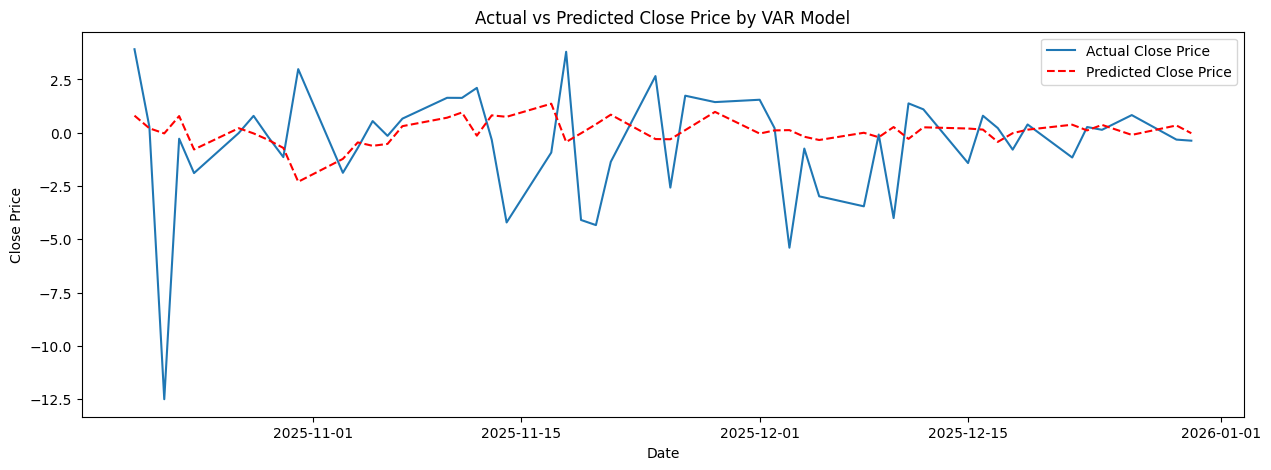

Root Mean Square Error : 3.01


In [12]:
from sklearn.metrics import mean_squared_error

predictions = results.forecast(train_data.values[-results.k_ar:], steps = len(test_data))

predictions = pd.DataFrame(predictions, index = test_data.index, columns = test_data.columns)

plt.figure(figsize=(15,5))
plt.plot(test_data.index, test_data['NFLX'], label = 'Actual Close Price')
plt.plot(test_data.index, predictions['NFLX'], color = 'red',linestyle = '--', label = 'Predicted Close Price')
plt.title('Actual vs Predicted Close Price by VAR Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

#model evaluation
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print(f'Root Mean Square Error : {rmse}')

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Test if AAPL helps predict NFLX
grangercausalitytests(data_diff[['NFLX','AAPL']], maxlag=4)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0600  , p=0.8066  , df_denom=244, df_num=1
ssr based chi2 test:   chi2=0.0608  , p=0.8053  , df=1
likelihood ratio test: chi2=0.0608  , p=0.8053  , df=1
parameter F test:         F=0.0600  , p=0.8066  , df_denom=244, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3190  , p=0.7272  , df_denom=241, df_num=2
ssr based chi2 test:   chi2=0.6512  , p=0.7221  , df=2
likelihood ratio test: chi2=0.6503  , p=0.7224  , df=2
parameter F test:         F=0.3190  , p=0.7272  , df_denom=241, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7490  , p=0.5239  , df_denom=238, df_num=3
ssr based chi2 test:   chi2=2.3132  , p=0.5100  , df=3
likelihood ratio test: chi2=2.3024  , p=0.5121  , df=3
parameter F test:         F=0.7490  , p=0.5239  , df_denom=238, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.5444  , p=0.7033  

{np.int64(1): ({'ssr_ftest': (np.float64(0.06004772482473222),
    np.float64(0.8066264892288562),
    np.float64(244.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.06078601652339696),
    np.float64(0.8052578949408302),
    np.int64(1)),
   'lrtest': (np.float64(0.06077853811507339),
    np.float64(0.8052696339665045),
    np.int64(1)),
   'params_ftest': (np.float64(0.06004772482472358),
    np.float64(0.8066264892288562),
    np.float64(244.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.31897071896974555),
    np.float64(0.7272032294476096),
    np.float64(241.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.6511767374818043),
    np.float64(0.7221023661696746),
    np.int64(2)),
   'lrtest': (np.float64(0.6503164034668316),
    np.float64(0.7224130576034398),
    np.int64(2)),
   'params_ftest': (np.float64(0.3189707189697257),
    np.float64(0.7272032294476292),
    np.float64(241.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
 

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Test if NFLX helps predict AAPL
grangercausalitytests(data_diff[['AAPL','NFLX']], maxlag=4)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.1542  , p=0.0770  , df_denom=244, df_num=1
ssr based chi2 test:   chi2=3.1930  , p=0.0740  , df=1
likelihood ratio test: chi2=3.1726  , p=0.0749  , df=1
parameter F test:         F=3.1542  , p=0.0770  , df_denom=244, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.2628  , p=0.1063  , df_denom=241, df_num=2
ssr based chi2 test:   chi2=4.6195  , p=0.0993  , df=2
likelihood ratio test: chi2=4.5766  , p=0.1014  , df=2
parameter F test:         F=2.2628  , p=0.1063  , df_denom=241, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.6467  , p=0.1793  , df_denom=238, df_num=3
ssr based chi2 test:   chi2=5.0855  , p=0.1656  , df=3
likelihood ratio test: chi2=5.0335  , p=0.1694  , df=3
parameter F test:         F=1.6467  , p=0.1793  , df_denom=238, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.7043  , p=0.0312  

{np.int64(1): ({'ssr_ftest': (np.float64(3.1542460317332788),
    np.float64(0.07697587755007834),
    np.float64(244.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(3.1930277452381963),
    np.float64(0.07395292268109246),
    np.int64(1)),
   'lrtest': (np.float64(3.1725653898479322),
    np.float64(0.0748847370449778),
    np.int64(1)),
   'params_ftest': (np.float64(3.1542460317332845),
    np.float64(0.07697587755007551),
    np.float64(244.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.262791982985102),
    np.float64(0.10626614725210722),
    np.float64(241.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(4.619475749496557),
    np.float64(0.09928727385059774),
    np.int64(2)),
   'lrtest': (np.float64(4.576638117115408),
    np.float64(0.10143682799396588),
    np.int64(2)),
   'params_ftest': (np.float64(2.2627919829851386),
    np.float64(0.1062661472521041),
    np.float64(241.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


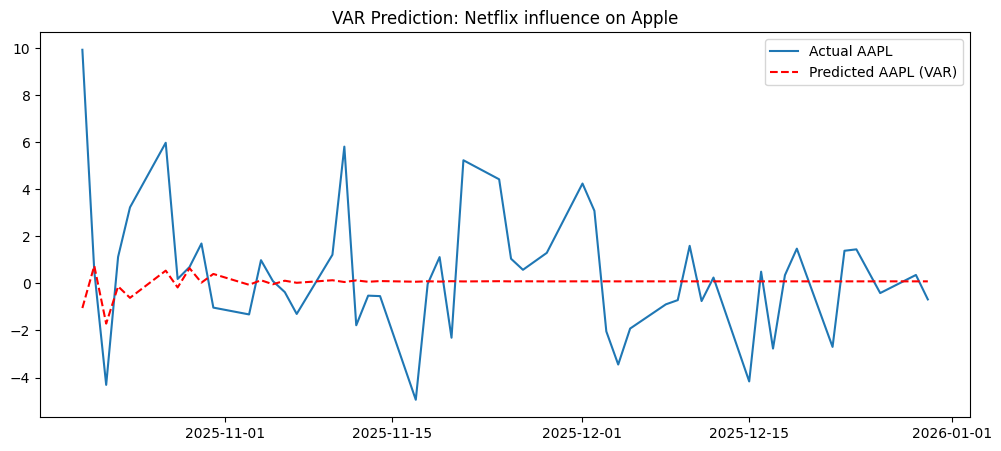

Root Mean Square Error : 3.01


In [13]:
from statsmodels.tsa.api import VAR

# Fit VAR model
model_var = VAR(train_data)
results_var = model_var.fit(maxlags=7)

# Forecast
pred_var = results_var.forecast(train_data.values[-results_var.k_ar:], steps=len(test_data))
pred_var = pd.DataFrame(pred_var, index=test_data.index, columns=test_data.columns)

# Plot AAPL actual vs predicted
plt.figure(figsize=(12,5))
plt.plot(test_data.index, test_data['AAPL'], label='Actual AAPL')
plt.plot(test_data.index, pred_var['AAPL'], linestyle='--', color='red', label='Predicted AAPL (VAR)')
plt.title('VAR Prediction: Netflix influence on Apple')
plt.legend()
plt.show()


#model evaluation
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print(f'Root Mean Square Error : {rmse}')

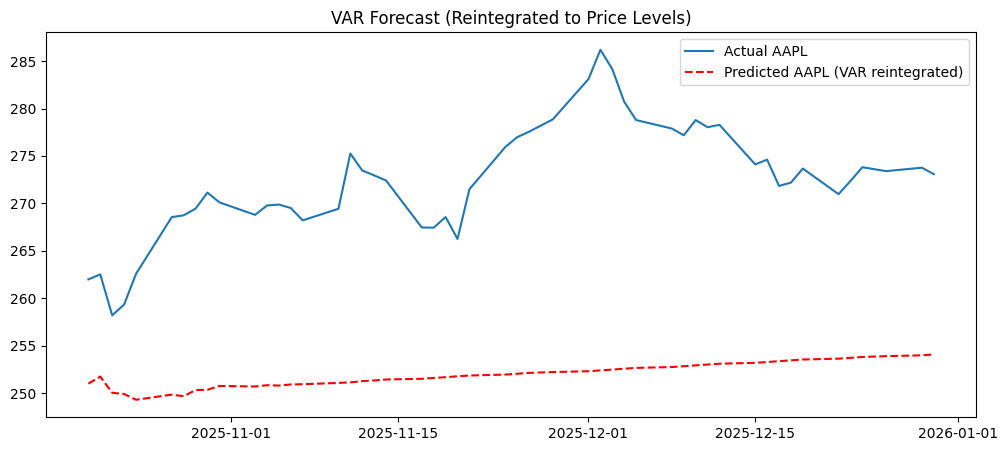

In [ ]:
# Forecast differenced values
pred_diff = results_var.forecast(train_data.values[-results_var.k_ar:], steps=len(test_data))
pred_diff = pd.DataFrame(pred_diff, index=test_data.index, columns=test_data.columns)

# Convert back to levels by cumulative sum + last observed level
last_obs = data.iloc[len(train_data)]  # last actual price before test set
pred_levels = pred_diff.cumsum() + last_obs.values

# Plot actual vs predicted AAPL
plt.figure(figsize=(12,5))
plt.plot(test_data.index, data.loc[test_data.index, 'AAPL'], label='Actual AAPL')
plt.plot(test_data.index, pred_levels['AAPL'], linestyle='--', color='red', label='Predicted AAPL (VAR reintegrated)')
plt.title('VAR Forecast (Reintegrated to Price Levels)')
plt.legend()
plt.show()


**2. VMA (Vector Moving Average)**

/tmp/ipython-input-594/2989419118.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


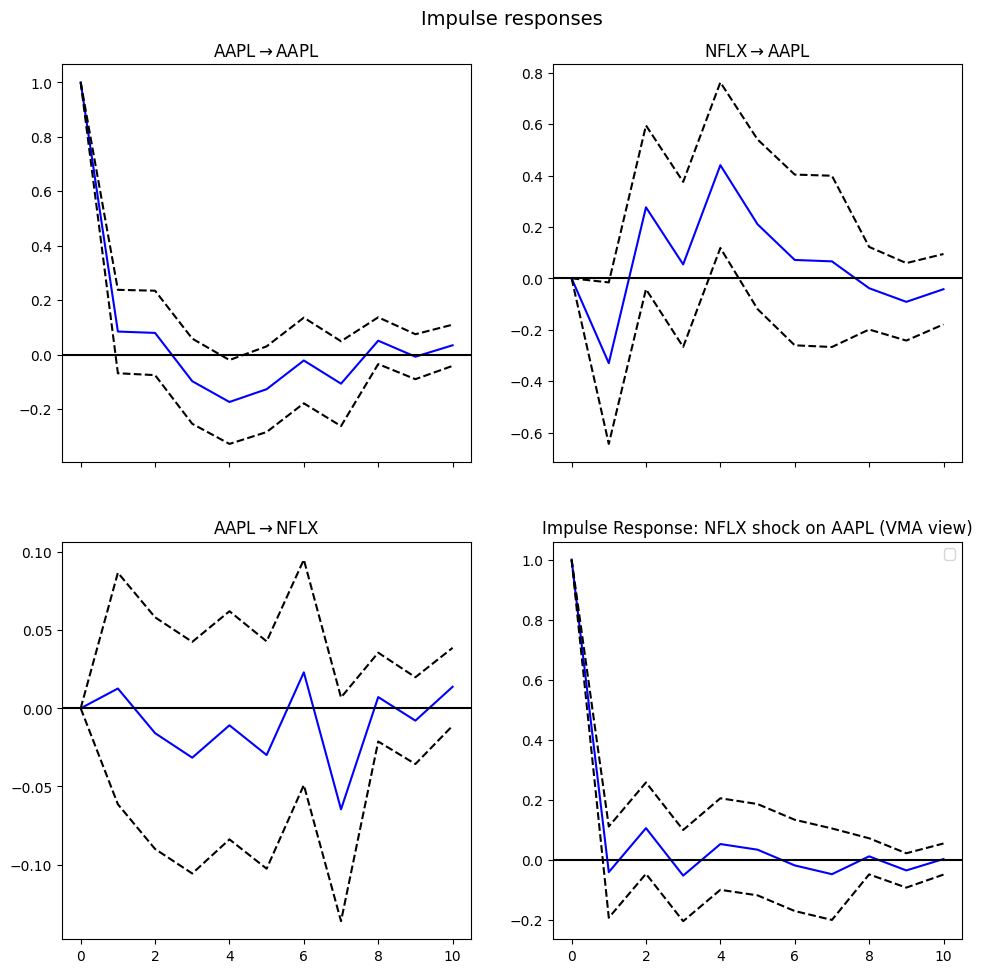

In [14]:
# Get VMA representation from VAR
vma_rep = results_var.ma_rep()

# Plot impulse response (shock in NFLX → effect on AAPL)
results_var.irf(10).plot(orth=False)
plt.title("Impulse Response: NFLX shock on AAPL (VMA view)")
plt.legend()
plt.show()


**3. VARMA (Vector Autoregressive Moving Average)**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_i

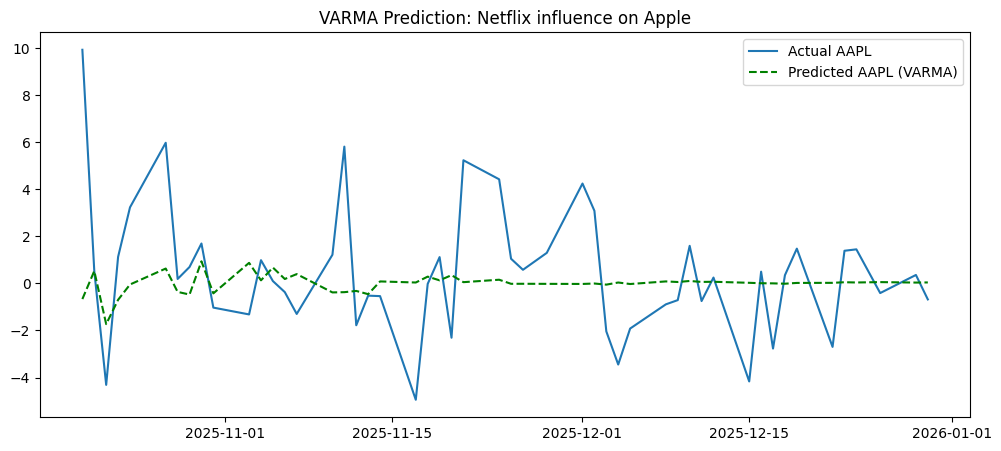

In [15]:
from statsmodels.tsa.statespace.varmax import VARMAX

# Fit VARMA (VARMAX with order=(p,q))
model_varma = VARMAX(train_data, order=(14,1))  # 14 lags AR, 1 lag MA
results_varma = model_varma.fit(disp=False)

# Forecast
pred_varma = results_varma.get_forecast(steps=len(test_data)).predicted_mean

# Plot AAPL actual vs predicted
plt.figure(figsize=(12,5))
plt.plot(test_data.index, test_data['AAPL'], label='Actual AAPL')
plt.plot(test_data.index, pred_varma['AAPL'], linestyle='--', color='green', label='Predicted AAPL (VARMA)')
plt.title('VARMA Prediction: Netflix influence on Apple')
plt.legend()
plt.show()


**VARIMA Model**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_i

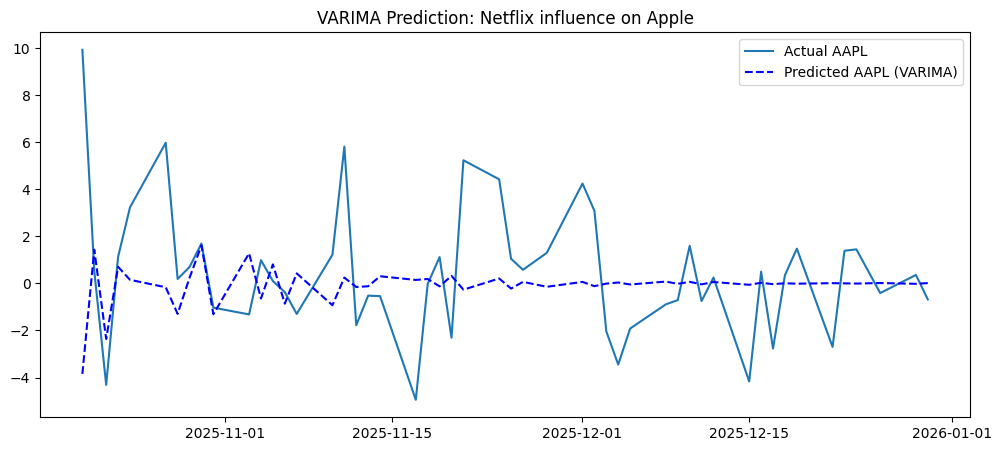

In [16]:
from statsmodels.tsa.statespace.varmax import VARMAX

# Fit VARIMA (VARMAX with order=(p,d,q))
# Here, d > 0 introduces differencing (integration)
train_data_diff = train_data.diff().dropna()
model_varima = VARMAX(train_data_diff, order=(14,1), trend='n')
results_varima = model_varima.fit(disp=False)

# Forecast
pred_varima = results_varima.get_forecast(steps=len(test_data)).predicted_mean

# Plot AAPL actual vs predicted
plt.figure(figsize=(12,5))
plt.plot(test_data.index, test_data['AAPL'], label='Actual AAPL')
plt.plot(test_data.index, pred_varima['AAPL'], linestyle='--', color='blue', label='Predicted AAPL (VARIMA)')
plt.title('VARIMA Prediction: Netflix influence on Apple')
plt.legend()
plt.show()
